In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd

In [40]:
train_df=pd.read_csv("SMS_train.csv",encoding='latin-1')
test_df=pd.read_csv("SMS_test.csv",encoding='latin-1')

In [10]:
train_df.head()

,S. No.,Message_body,Label
0,1,Rofl. Its true to its name,Non-Spam
1,2,The guy did some bitching but I acted like i'd...,Non-Spam
2,3,"Pity, * was in mood for that. So...any other s...",Non-Spam
3,4,Will ü b going to esplanade fr home?,Non-Spam
4,5,This is the 2nd time we have tried 2 contact u...,Spam


In [11]:
train_df.shape

(957, 3)

In [43]:
test_df.shape

(125, 3)

In [12]:
train_df.isna().sum()

S. No.          0
Message_body    0
Label           0
dtype: int64

In [42]:
test_df.isna().sum()

S. No.          0
Message_body    0
Label           0
dtype: int64

In [13]:
train_df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Label', ylabel='count'>

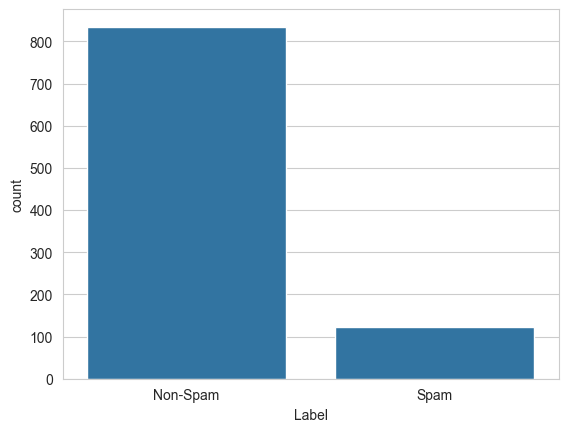

In [14]:
sns.set_style('whitegrid')
sns.countplot(x=train_df['Label'])

In [20]:
train_df['Label'].value_counts(ascending=False,normalize=True)*100

Label
Non-Spam    87.251829
Spam        12.748171
Name: proportion, dtype: float64

In [172]:
X_train=train_df['Message_body']
y_train=train_df['Label']

In [173]:
X_test=test_df['Message_body']
y_test=test_df['Label']

In [27]:
import string 
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\3PIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\3PIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\3PIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [65]:
stop_words=set(stopwords.words('english'))
('not' in stop_words)

True

In [96]:
stop_words.remove('not')

In [84]:
import re
import string

def text_preprocess(text):
    # 1. Lowercase (Bilkul sahi)
    text = text.lower()
    
    # 2. URLs hatana (Pehle ye karo, warna punctuation URLs ko tod dega)
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 3. Punctuation hatana
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    
    # 5. Sirf a-z aur spaces rakhna (Extra safety)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 6. Extra spaces hatana (\s+ is correct)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [85]:
X_test.head()

0    upgrdcentre orange customer may claim free cam...
1    loan purpose homeowners tenants welcome previo...
2    congrats nokia video camera phone call calls c...
3    urgent mobile number awarded prize guaranteed ...
4    someone contacted dating service entered phone...
Name: Message_body, dtype: object

In [86]:
X_train=X_train.apply(text_preprocess)
X_test=X_test.apply(text_preprocess)

In [90]:
len(X_train[X_train.str.contains('not')])

18

In [91]:
X_train[X_train.str.contains('not')]

36                                     ok another number
103    get garden ready summer free selection summer ...
121    latest news police station toilet stolen cops ...
185    friends help us problems give stupid suggestio...
222    sir thats hr trip bus last week another auditi...
300    dont prize go another customer tc pmin polo lt...
321                   u come n search tat vidnot finishd
370    shes fine difficulties phone works mine pls se...
421    get garden ready summer free selection summer ...
482          omg one thing another cat worms bad day end
577    telling coulda real valentine wasnt u never pi...
652    youve already got flaky parent itsnot supposed...
663                            im reaching another stops
678    pls make note shes exposed also find school an...
814       well boy glad g wasted night applebees nothing
836     dont know ask brother nothing problem thing told
897    born god said oh another idiot born god said o...
900                            

In [92]:
len(X_test[X_test.str.contains('not')])

1

In [93]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger_eng',quiet=True)
nltk.download('wordnet',quiet=True)
lemmatizer=WordNetLemmatizer()

In [95]:
def get_word_tag_pos(nltk_tag):

    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    else:
        return wordnet.NOUN

def text_lemmatizer(text):
    tokens=word_tokenize(text.lower())
    tokens=[word for word in tokens if word not in stop_words]
    pos_tags=pos_tag(tokens)

    lemmatized=[]
    for word,tag in pos_tags:
        wordnet_pos=get_word_tag_pos(tag)
        lemma=lemmatizer.lemmatize(word,pos=wordnet_pos)
        lemmatized.append(lemma)
    return ' '.join(lemmatized)    

In [94]:
X_train=X_train.apply(text_lemmatizer)
X_test=X_test.apply(text_lemmatizer)

In [102]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

bow=CountVectorizer()
X_train_bow=bow.fit_transform(X_train)
X_test_bow=bow.transform(X_test)
X_train_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7537 stored elements and shape (957, 2586)>

In [103]:
X_train_bow.shape

(957, 2586)

In [122]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(k_neighbors=5,random_state=42)
X_train_res,y_train_res=smote.fit_resample(X_train_bow,y_train)

In [123]:
X_train_res.shape

(1670, 2586)

In [181]:
y_train_res=y_train_res.map({
    'Non-Spam':0,
    'Spam':1
})
y_train=y_train.map({
    'Non-Spam':0,
    'Spam':1
})
y_test=y_test.map({
    'Non-Spam':0,
    'Spam':1
})

In [180]:
from sklearn.naive_bayes import MultinomialNB


model_multi_nb=MultinomialNB()
model_multi_nb.fit(X_train_res,y_train_res)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [157]:
y_train_res.head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Label, dtype: float64

In [127]:
y_test.head()

0    1
1    1
2    1
3    1
4    1
Name: Label, dtype: int64

Accuracy: 0.888%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        49
           1       0.96      0.86      0.90        76

    accuracy                           0.89       125
   macro avg       0.88      0.90      0.89       125
weighted avg       0.90      0.89      0.89       125

AUC-ROC Score: 0.9492481203007519


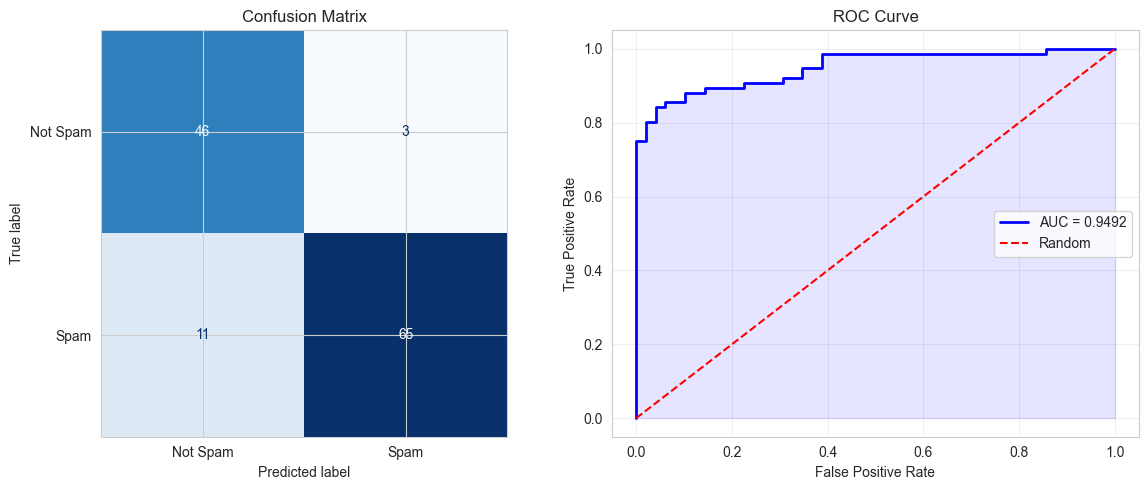

In [138]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, roc_curve)
import matplotlib.pyplot as plt

# ── Predictions ───────────────────────────────
y_pred_bow       = model_multi_nb.predict(X_test_bow)
y_pred_proba_bow = model_multi_nb.predict_proba(X_test_bow)[:, 1]  # probability of class 1

# ── 1. Accuracy ───────────────────────────────
print(f"Accuracy: {accuracy_score(y_test, y_pred_bow)}%")

# ── 2. Classification Report ──────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bow))

# ── 3. AUC-ROC Score ──────────────────────────
auc1 = roc_auc_score(y_test, y_pred_proba_bow)
print("AUC-ROC Score:", auc)

# ── 4. Confusion Matrix + ROC Curve (side by side) ──
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm1 = confusion_matrix(y_test, y_pred_bow)
disp1 = ConfusionMatrixDisplay(cm1,display_labels=['Not Spam','Spam'])
disp1.plot(ax=axes1[0], cmap='Blues', colorbar=False)
axes1[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_bow)
axes1[1].plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc:.4f}')
axes1[1].plot([0,1], [0,1], 'r--', label='Random')
axes1[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes1[1].set_xlabel('False Positive Rate')
axes1[1].set_ylabel('True Positive Rate')
axes1[1].set_title('ROC Curve')
axes1[1].legend()
axes1[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [183]:
tfidf=TfidfVectorizer()
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [175]:
X_train_tfidf.shape

(957, 3154)

In [176]:
pd.DataFrame(X_train_tfidf.toarray(),columns=tfidf.get_feature_names_out())

,000,0121,02,0207,02073162414,03,04,05,06,07099833605,...,yours,yourself,yoville,yr,yummy,yuo,yup,zebra,zed,zeros
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
952,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
953,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
954,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
955,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [177]:
X_test_tfidf.shape

(125, 3154)

In [184]:
from sklearn.linear_model import LogisticRegression

logistic_model=LogisticRegression(class_weight='balanced')
logistic_model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Accuracy: 0.928%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91        49
           1       0.99      0.89      0.94        76

    accuracy                           0.93       125
   macro avg       0.92      0.94      0.93       125
weighted avg       0.94      0.93      0.93       125

AUC-ROC Score: 0.9492481203007519


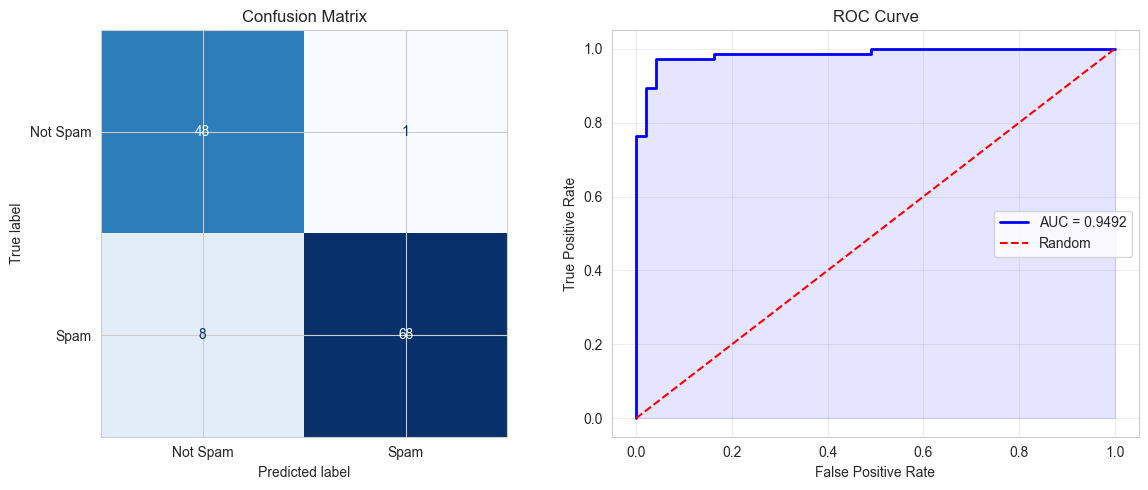

In [185]:

# ── Predictions ───────────────────────────────
y_pred_tfidf       = logistic_model.predict(X_test_tfidf)
y_pred_proba_tfidf = logistic_model.predict_proba(X_test_tfidf)[:, 1]  # probability of class 1

# ── 1. Accuracy ───────────────────────────────
print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf)}%")

# ── 2. Classification Report ──────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf))

# ── 3. AUC-ROC Score ──────────────────────────
auc1 = roc_auc_score(y_test, y_pred_proba_tfidf)
print("AUC-ROC Score:", auc)

# ── 4. Confusion Matrix + ROC Curve (side by side) ──
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred_tfidf)
disp2 = ConfusionMatrixDisplay(cm2,display_labels=['Not Spam','Spam'])
disp2.plot(ax=axes2[0], cmap='Blues', colorbar=False)
axes2[0].set_title('Confusion Matrix')

# ROC Curve
fpr2, tpr2, _ = roc_curve(y_test, y_pred_proba_tfidf)
axes2[1].plot(fpr2, tpr2, color='blue', linewidth=2, label=f'AUC = {auc:.4f}')
axes2[1].plot([0,1], [0,1], 'r--', label='Random')
axes2[1].fill_between(fpr2, tpr2, alpha=0.1, color='blue')
axes2[1].set_xlabel('False Positive Rate')
axes2[1].set_ylabel('True Positive Rate')
axes2[1].set_title('ROC Curve')
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

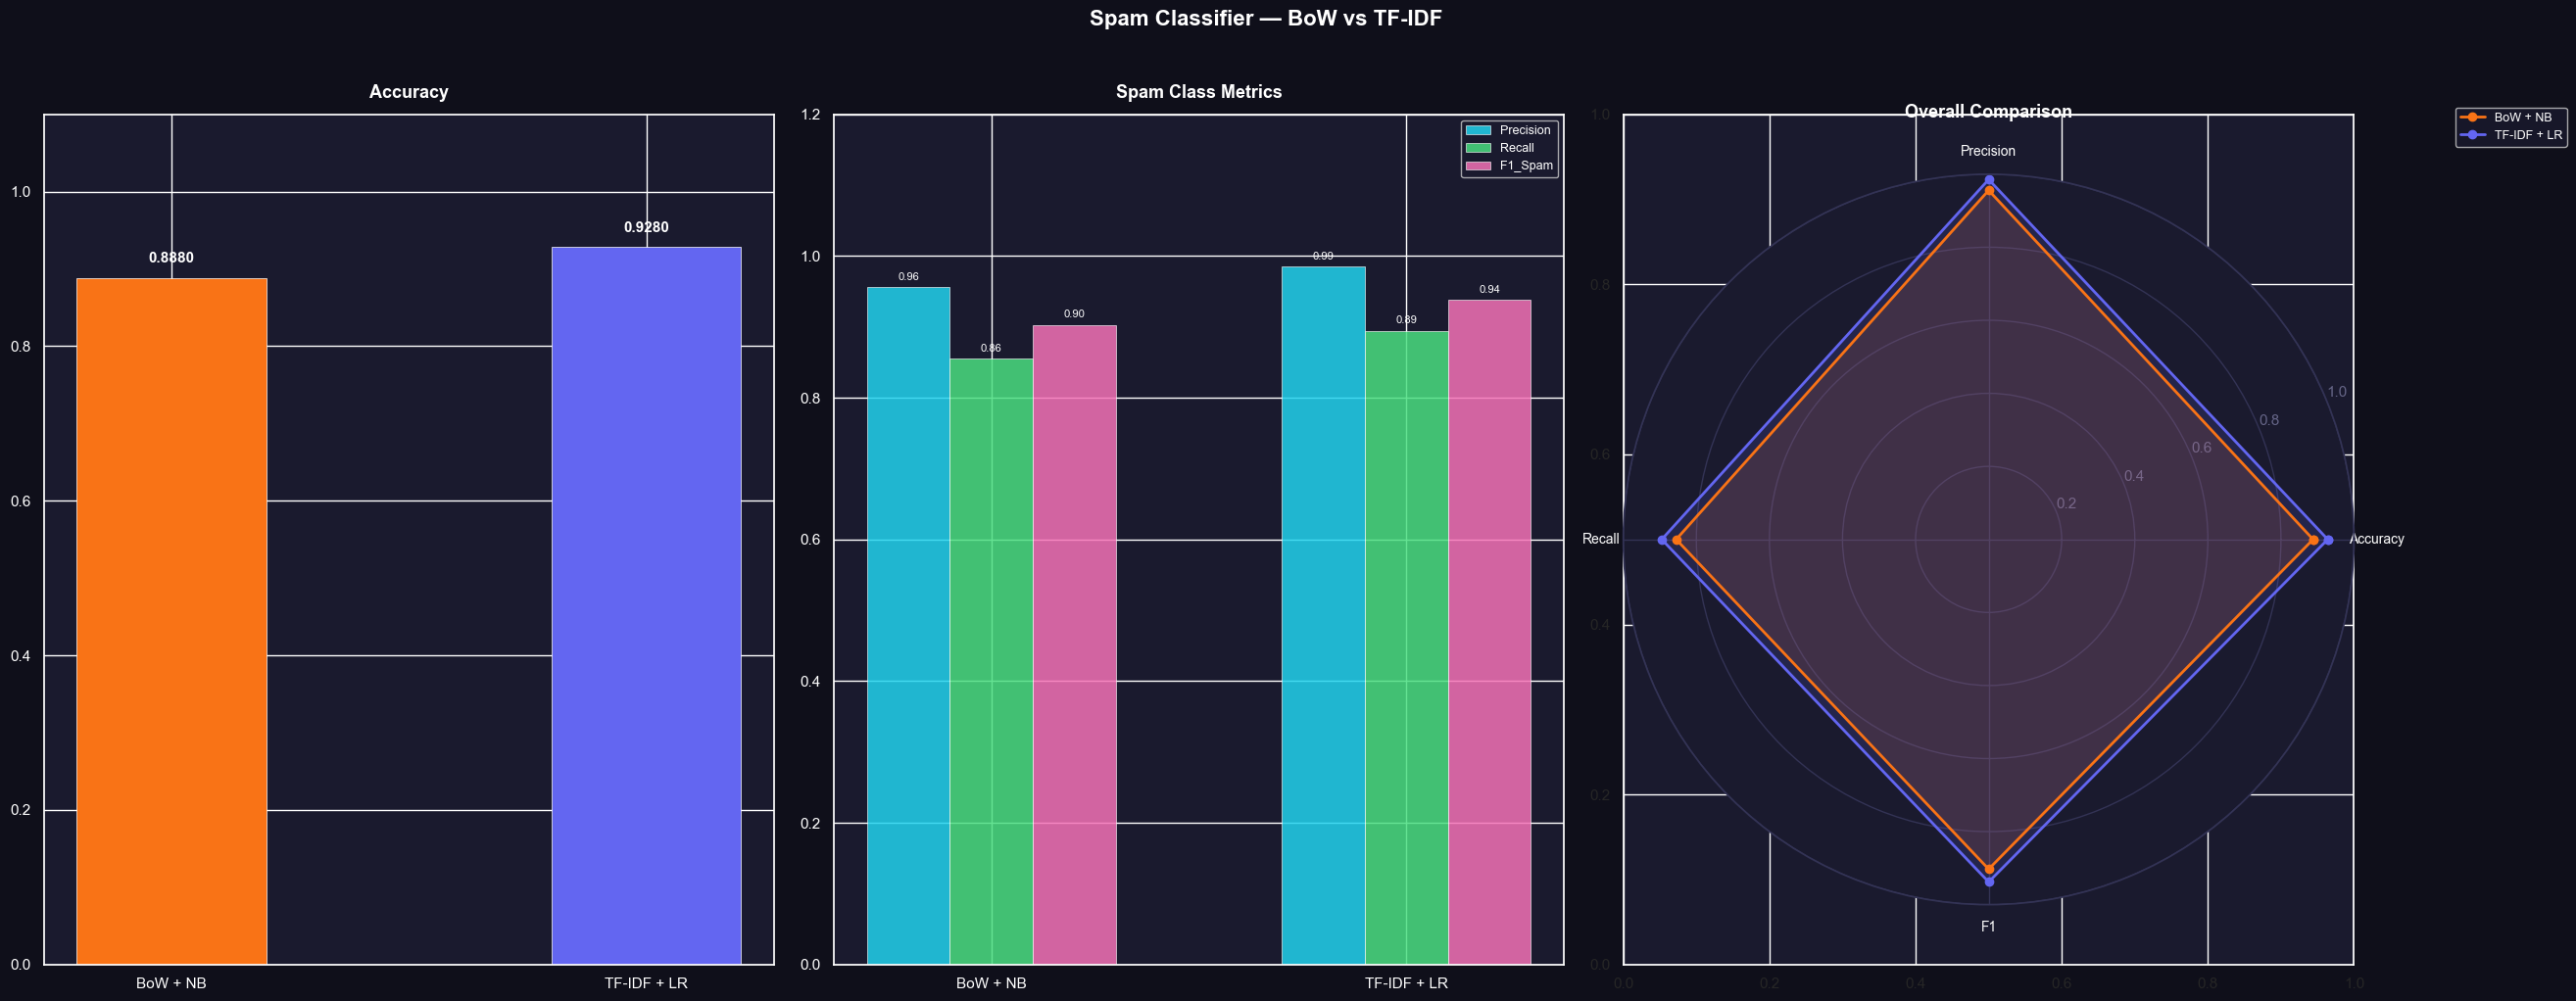

In [191]:
# ── Data Prepare karo ──────────────────────────
results = pd.DataFrame({
    'Model':    ['BoW + NB', 'TF-IDF + LR'],
    'Accuracy': [accuracy_score(y_test, y_pred_bow),
                 accuracy_score(y_test, y_pred_tfidf)],
    'F1_Spam':  [
        float(classification_report(y_test, y_pred_bow,   output_dict=True)['1']['f1-score']),
        float(classification_report(y_test, y_pred_tfidf, output_dict=True)['1']['f1-score'])
    ],
    'Precision': [
        float(classification_report(y_test, y_pred_bow,   output_dict=True)['1']['precision']),
        float(classification_report(y_test, y_pred_tfidf, output_dict=True)['1']['precision'])
    ],
    'Recall': [
        float(classification_report(y_test, y_pred_bow,   output_dict=True)['1']['recall']),
        float(classification_report(y_test, y_pred_tfidf, output_dict=True)['1']['recall'])
    ]
})

# ── Plot Setup ─────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
fig3, axes3 = plt.subplots(1, 3, figsize=(26, 10))
fig3.patch.set_facecolor('#0f0f1a')
for ax3 in axes3:
    ax3.set_facecolor('#1a1a2e')

COLORS = ['#f97316', '#6366f1']

# ── Plot 1: Accuracy Bar ───────────────────────
bars3 = axes3[0].bar(results['Model'], results['Accuracy'],
                     color=COLORS, width=0.4,
                     edgecolor='white', linewidth=0.5)
axes3[0].set_title('Accuracy', color='white', fontsize=13, fontweight='bold', pad=12)
axes3[0].set_ylim(0, 1.1)
axes3[0].tick_params(colors='white')
axes3[0].yaxis.label.set_color('white')
for bar3, val3 in zip(bars3, results['Accuracy']):
    axes3[0].text(bar3.get_x() + bar3.get_width()/2,
                  bar3.get_height() + 0.02,
                  f'{val3:.4f}', ha='center', color='white',
                  fontsize=11, fontweight='bold')

# ── Plot 2: Grouped Bar — Precision/Recall/F1 ─
x3 = np.arange(len(results['Model']))
w3 = 0.2
metrics3 = ['Precision', 'Recall', 'F1_Spam']
metric_colors3 = ['#22d3ee', '#4ade80', '#f472b6']

for i3, (metric3, color3) in enumerate(zip(metrics3, metric_colors3)):
    bars3 = axes3[1].bar(x3 + i3*w3, results[metric3],
                         width=w3, label=metric3,
                         color=color3, alpha=0.85,
                         edgecolor='white', linewidth=0.5)
    for bar3, val3 in zip(bars3, results[metric3]):
        axes3[1].text(bar3.get_x() + bar3.get_width()/2,
                      bar3.get_height() + 0.01,
                      f'{val3:.2f}', ha='center',
                      color='white', fontsize=8)

axes3[1].set_title('Spam Class Metrics', color='white',
                   fontsize=13, fontweight='bold', pad=12)
axes3[1].set_xticks(x3 + w3)
axes3[1].set_xticklabels(results['Model'], color='white')
axes3[1].set_ylim(0, 1.2)
axes3[1].tick_params(colors='white')
axes3[1].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)

# ── Plot 3: Radar Chart ────────────────────────
categories3 = ['Accuracy', 'Precision', 'Recall', 'F1']
N3 = len(categories3)
angles3 = [n3 / float(N3) * 2 * np.pi for n3 in range(N3)]
angles3 += angles3[:1]

radar3 = plt.subplot(133, polar=True)
radar3.set_facecolor('#1a1a2e')

for idx3, (_, row3) in enumerate(results.iterrows()):
    values3 = [row3['Accuracy'], row3['Precision'],
               row3['Recall'],   row3['F1_Spam']]
    values3 += values3[:1]
    radar3.plot(angles3, values3, 'o-', linewidth=2,
                color=COLORS[idx3], label=row3['Model'])
    radar3.fill(angles3, values3, alpha=0.15, color=COLORS[idx3])

radar3.set_xticks(angles3[:-1])
radar3.set_xticklabels(categories3, color='white', fontsize=10)
radar3.set_ylim(0, 1)
radar3.tick_params(colors='white')
radar3.set_title('Overall Comparison', color='white',
                  fontsize=13, fontweight='bold', pad=20)
radar3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1),
              facecolor='#1a1a2e', labelcolor='white', fontsize=9)
radar3.spines['polar'].set_color('#333355')
radar3.yaxis.set_tick_params(labelcolor='#666688')
radar3.grid(color='#333355')

# ── Final ──────────────────────────────────────
fig3.suptitle('Spam Classifier — BoW vs TF-IDF',
              color='white', fontsize=16,
              fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('spam_results.png', dpi=150,
            bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()